In [16]:
import os
import pandas as pd
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
from enhanced_data_generator import DarkPoolDataGenerator

In [7]:
generator = DarkPoolDataGenerator(random_seed=42)
    
# Generate enhanced dataset
enhanced_df, fraud_metadata = generator.generate_enhanced_dataset(
    num_transactions=400000, 
    fraud_rate=0.10  # 10% fraud rate for educational purposes
)

# Use relative paths for portability
data_dir = './data'

# Create data directory if it doesn't exist
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

# Save enhanced raw data
output_path = os.path.join(data_dir, 'enhanced_raw_data.csv')
enhanced_df.to_csv(output_path, index=False)
print(f"Enhanced dataset saved to: {output_path}")

# Save fraud metadata for validation
fraud_df = pd.DataFrame(fraud_metadata)
fraud_path = os.path.join(data_dir, 'fraud_patterns_metadata.csv')
fraud_df.to_csv(fraud_path, index=False)
print(f"Fraud metadata saved to: {fraud_path}")

# return enhanced_df, fraud_metadata

Generating 400,000 enhanced dark pool transactions...
Generated 20,000 transactions...
Generated 40,000 transactions...
Generated 60,000 transactions...
Generated 80,000 transactions...
Generated 100,000 transactions...
Generated 120,000 transactions...
Generated 140,000 transactions...
Generated 160,000 transactions...
Generated 180,000 transactions...
Generated 200,000 transactions...
Generated 220,000 transactions...
Generated 240,000 transactions...
Generated 260,000 transactions...
Generated 280,000 transactions...
Generated 300,000 transactions...
Generated 320,000 transactions...
Generated 340,000 transactions...
Generated 360,000 transactions...
Generated 380,000 transactions...
Generated 400,000 transactions...
Injecting fraud patterns (10.0% fraud rate)...
Enhanced dataset generation complete!
Enhanced dataset saved to: ./data/enhanced_raw_data.csv
Fraud metadata saved to: ./data/fraud_patterns_metadata.csv


In [ ]:
print(len(fraud_df))
print(fraud_df.head().to_markdown())

40000
|    |   index | type         | pattern             |
|---:|--------:|:-------------|:--------------------|
|  0 |  265534 | structuring  | threshold_avoidance |
|  1 |   47517 | structuring  | threshold_avoidance |
|  2 |  360581 | wash_trading | circular_amounts    |
|  3 |  269170 | layering     | round_amount        |
|  4 |  361357 | layering     | round_amount        |


In [9]:
print(len(enhanced_df))
print(enhanced_df.head().to_markdown())

400000
|    | Timestamp           |   TransactionID |   AccountID |          Amount | Merchant   | TransactionType   | Location      |
|---:|:--------------------|----------------:|------------:|----------------:|:-----------|:------------------|:--------------|
|  0 | 2023-01-01 06:03:00 |          308153 |           6 | 100000          | J          | Withdrawal        | New York      |
|  1 | 2023-01-01 06:03:00 |          269299 |           3 | 105628          | J          | Transfer          | New York      |
|  2 | 2023-01-01 06:16:00 |          331884 |          13 |      1.0421e+06 | B          | Purchase          | San Francisco |
|  3 | 2023-01-01 06:41:00 |           66564 |          14 | 297872          | B          | Purchase          | New York      |
|  4 | 2023-01-01 06:55:00 |           38295 |           2 | 334514          | J          | Transfer          | New York      |


Performing Benford's Law analysis on complete dataset...


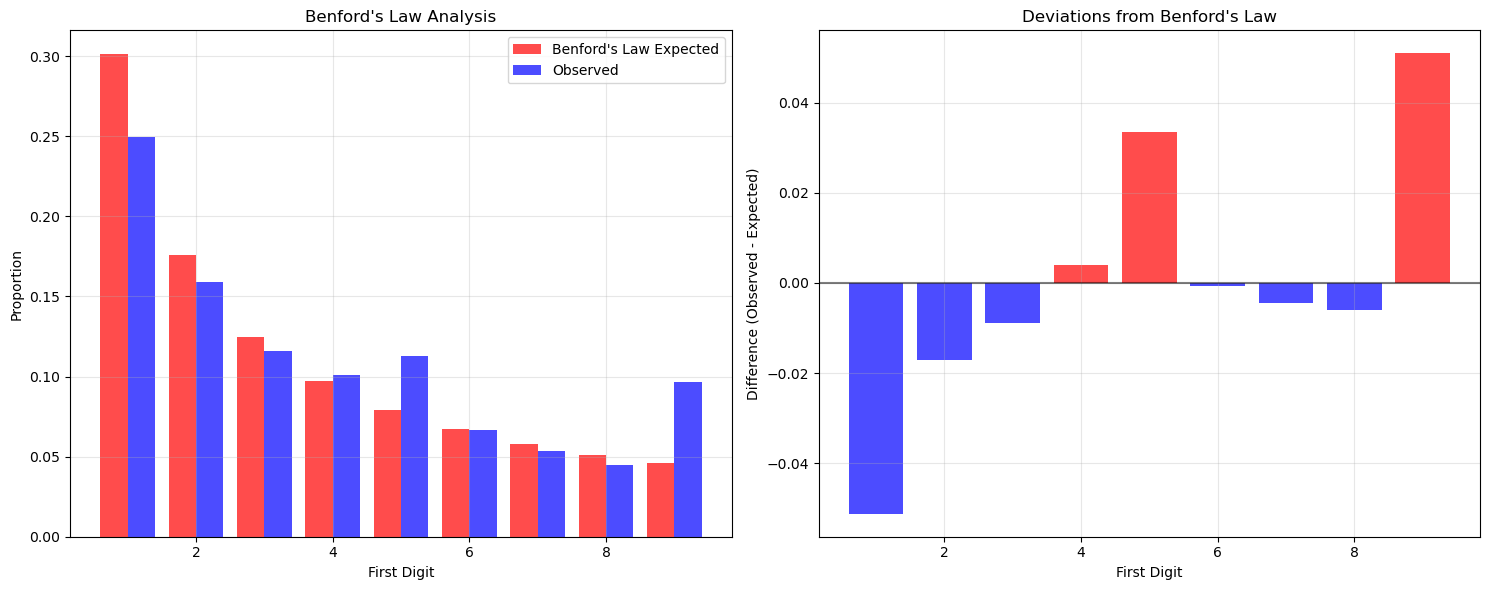


=== Benford's Law Analysis Results ===
Sample size: 400,000
Chi-squared statistic: 33277.3531
P-value: 0.000000
Euclidean distance: 0.0824
Is anomalous (α=0.05): True

⚠️  ALERT: This dataset significantly deviates from Benford's Law!
   Further investigation with advanced clustering is warranted.


In [17]:


def benford_analysis(data, amount_column='Amount', significance_level=0.05):
    """
    Implement Benford's Law analysis for fraud detection
    """
    # Extract first digits from amounts
    amounts = data[amount_column].dropna()
    first_digits = amounts.astype(str).str[0].astype(int)
    
    # Calculate observed frequencies
    observed_counts = first_digits.value_counts().sort_index()
    observed_proportions = observed_counts / len(first_digits)
    
    # Calculate expected Benford proportions
    benford_proportions = pd.Series(
        [np.log10(1 + 1/d) for d in range(1, 10)], 
        index=range(1, 10)
    )
    
    # Ensure both series have the same index
    for digit in range(1, 10):
        if digit not in observed_proportions.index:
            observed_proportions[digit] = 0
    observed_proportions = observed_proportions.sort_index()
    
    # Calculate chi-squared statistic
    expected_counts = benford_proportions * len(first_digits)
    chi_squared = np.sum((observed_counts - expected_counts)**2 / expected_counts)
    
    # Calculate p-value (8 degrees of freedom for 9 categories - 1)
    p_value = 1 - stats.chi2.cdf(chi_squared, df=8)
    
    # Calculate Euclidean distance
    euclidean_distance = np.sqrt(np.sum((observed_proportions - benford_proportions)**2))
    
    # Determine if anomalous
    is_anomalous = p_value < significance_level
    
    return {
        'observed_proportions': observed_proportions,
        'benford_proportions': benford_proportions,
        'chi_squared': chi_squared,
        'p_value': p_value,
        'euclidean_distance': euclidean_distance,
        'is_anomalous': is_anomalous,
        'sample_size': len(first_digits)
    }

def visualize_benford_analysis(benford_results):
    """
    Visualize Benford's Law analysis results
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot distributions
    digits = range(1, 10)
    ax1.bar([d - 0.2 for d in digits], benford_results['benford_proportions'], 
            width=0.4, label='Benford\'s Law Expected', alpha=0.7, color='red')
    ax1.bar([d + 0.2 for d in digits], benford_results['observed_proportions'], 
            width=0.4, label='Observed', alpha=0.7, color='blue')
    ax1.set_xlabel('First Digit')
    ax1.set_ylabel('Proportion')
    ax1.set_title('Benford\'s Law Analysis')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot differences
    differences = benford_results['observed_proportions'] - benford_results['benford_proportions']
    colors = ['red' if d > 0 else 'blue' for d in differences]
    ax2.bar(digits, differences, color=colors, alpha=0.7)
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    ax2.set_xlabel('First Digit')
    ax2.set_ylabel('Difference (Observed - Expected)')
    ax2.set_title('Deviations from Benford\'s Law')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistical results
    print(f"\n=== Benford's Law Analysis Results ===")
    print(f"Sample size: {benford_results['sample_size']:,}")
    print(f"Chi-squared statistic: {benford_results['chi_squared']:.4f}")
    print(f"P-value: {benford_results['p_value']:.6f}")
    print(f"Euclidean distance: {benford_results['euclidean_distance']:.4f}")
    print(f"Is anomalous (α=0.05): {benford_results['is_anomalous']}")
    
    if benford_results['is_anomalous']:
        print("\n⚠️  ALERT: This dataset significantly deviates from Benford's Law!")
        print("   Further investigation with advanced clustering is warranted.")
    else:
        print("\n✅ This dataset appears to follow Benford's Law within normal bounds.")

# Perform Benford's Law analysis on the complete dataset
print("Performing Benford's Law analysis on complete dataset...")
benford_results = benford_analysis(enhanced_df)
visualize_benford_analysis(benford_results)

In [19]:
print(enhanced_df.columns)

Index(['Timestamp', 'TransactionID', 'AccountID', 'Amount', 'Merchant',
       'TransactionType', 'Location'],
      dtype='object')


KeyError: 'Quarter'

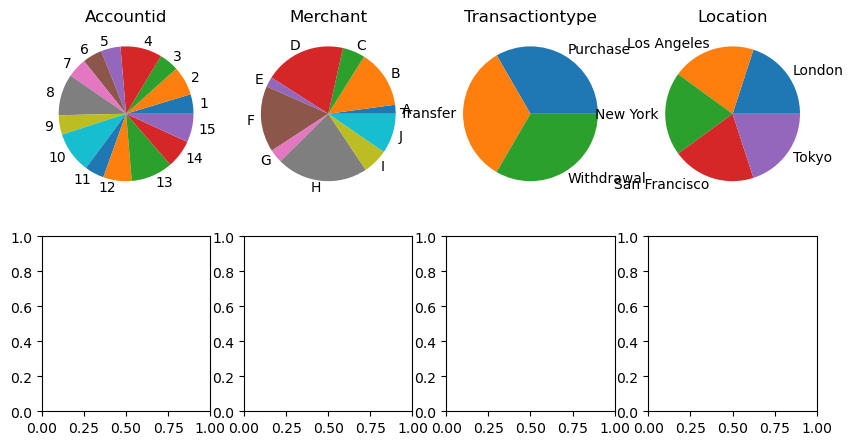

In [18]:
# Check for Amount Sum across categories
fig, axs = plt.subplots(2, 4, figsize=(10, 5)) 
axs = axs.flatten()
for i, col in enumerate(['AccountID', 'Merchant','TransactionType','Location','Quarter','Month','Day_Of_Week', 'Hour']):
    grouped = enhanced_df.groupby(col)['Amount'].sum()
    grouped.plot(kind='pie', ax=axs[i])
    axs[i].set_ylabel('')
    axs[i].set_title(col.title())

fig.suptitle('Share of Amount by Grouping', fontsize=16)
plt.show()